In [3]:
import shap

In [4]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# 版本查詢

In [1]:
import platform
print(platform.python_version())


3.12.3


In [6]:

import sklearn
import xgboost
import catboost

print("Scikit-learn version:", sklearn.__version__)
print("XGBoost version:", xgboost.__version__)
print("CatBoost version:", catboost.__version__)


# 顯示安裝來源 (pip show)
!pip show scikit-learn | grep -E "Name|Version|Home-page"
!pip show xgboost | grep -E "Name|Version|Home-page"
!pip show catboost | grep -E "Name|Version|Home-page"


Scikit-learn version: 1.6.1
XGBoost version: 2.1.3
CatBoost version: 1.2.8
Name: scikit-learn
Version: 1.6.1
Home-page: https://scikit-learn.org
 Name: GCC runtime library
 Version 3.1, 31 March 2009
Name: xgboost
Version: 2.1.3
Home-page: 
Name: catboost
Version: 1.2.8
Home-page: https://catboost.ai
License: Apache License, Version 2.0


In [7]:
import importlib.metadata

print(importlib.metadata.metadata("scikit-learn")["Version"])
print(importlib.metadata.metadata("xgboost")["Version"])
print(importlib.metadata.metadata("catboost")["Version"])


1.6.1
2.1.3
1.2.8


In [9]:
print(shap.__version__)

0.48.0


# 最原始資料匯入並分成訓練、內部測試、外部測試


In [1]:
import pandas as pd
new_data = pd.read_excel(
    r"RTOC_provide20251009.xlsx")

In [ ]:
new_data  # 顯示前幾列確認資料成功載入

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split

# 檢查編碼與缺失
try:
    assert set(df['Institute'].unique()) <= {0, 1}, "Institute 應為 0=MMH, 1=CCH"
    if df['Muscle_loss'].isna().any():
        raise ValueError("CCH 中有 Muscle_loss 缺失，請先處理再切分。")

    # 固定 MMH 為外部驗證 Group=2
    df.loc[df['Institute'] == 0, 'Group'] = 2

    # 取出 CCH 並做分層切分（依 Muscle_loss）
    cch = df[df['Institute'] == 1].copy()
    X = cch[['ID']]                     # 只需要索引
    y = cch['Muscle_loss'].astype(int)  # 分層標籤 (0/1)

    # 確保 ID 欄位在 df 中存在
    if 'ID' not in X.columns:
        raise KeyError("資料集中必須包含 'ID' 欄位用於分層追蹤。")

    id_train, id_test = train_test_split(
        X['ID'],
        test_size=0.3,
        stratify=y,
        random_state=42
    )

    # 標記 CCH：訓練=0、內測=1
    df.loc[df['ID'].isin(id_train), 'Group'] = 0
    df.loc[df['ID'].isin(id_test),  'Group'] = 1

    train_set = df[df['Group'] == 0].copy()
    internal_test_set = df[df['Group'] == 1].copy()
    External_set = df[df['Group'] == 2].copy()
    
    # 驗證分佈（原始 CCH vs 訓練/內測）
    def pct(s):  # 回傳百分比
        vc = s.value_counts().sort_index()
        return (vc / vc.sum()).rename(lambda k: f'class_{k}')

    orig_dist = pct(cch['Muscle_loss'])
    train_dist = pct(train_set['Muscle_loss'])
    test_dist  = pct(internal_test_set['Muscle_loss'])

    print("=== CCH 原始分佈 (Muscle_loss) ===")
    print(orig_dist)
    print("\n=== 訓練集分佈 ===")
    print(train_dist)
    print("\n=== 內部測試集分佈 ===")
    print(test_dist)

    # 簡單檢查：分佈差異
    diff_train = (train_dist - orig_dist).abs().fillna(0)
    diff_test  = (test_dist  - orig_dist).abs().fillna(0)
    print("\n|訓練集| 與原始分佈差異：")
    print(diff_train)
    print("\n|內部測試| 與原始分佈差異：")
    print(diff_test)

    # 查看各組筆數與儲存檔案
    print("\n=== 各組筆數 ===")
    print(f"train_set (Group=0, CCH, 70%): {len(train_set)} 筆")
    print(f"internal_test_set (Group=1, CCH, 30%): {len(internal_test_set)} 筆")
    print(f"External_set (Group=2, MMH, 100%): {len(External_set)} 筆")
    print(f"總筆數: {len(train_set) + len(internal_test_set) + len(External_set)} 筆")

except Exception as e:
    print(f"\n[執行錯誤]：{e}")

=== CCH 原始分佈 (Muscle_loss) ===
Muscle_loss
class_0    0.738994
class_1    0.261006
Name: count, dtype: float64

=== 訓練集分佈 ===
Muscle_loss
class_0    0.739326
class_1    0.260674
Name: count, dtype: float64

=== 內部測試集分佈 ===
Muscle_loss
class_0    0.73822
class_1    0.26178
Name: count, dtype: float64

|訓練集| 與原始分佈差異：
Muscle_loss
class_0    0.000332
class_1    0.000332
Name: count, dtype: float64

|內部測試| 與原始分佈差異：
Muscle_loss
class_0    0.000774
class_1    0.000774
Name: count, dtype: float64

=== 各組筆數 ===
train_set (Group=0, CCH, 70%): 445 筆
internal_test_set (Group=1, CCH, 30%): 191 筆
External_set (Group=2, MMH, 100%): 388 筆
總筆數: 1024 筆


In [ ]:
# 檢查
train_set

In [ ]:
internal_test_set

In [ ]:
External_set

In [ ]:
# 定義輸出檔案名稱
output_filename = 'RTOC_provide20251009_model2_grouped.xlsx'

# 建立 ExcelWriter 
with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
    train_set.to_excel(writer, sheet_name='Train', index=False)
    internal_test_set.to_excel(writer, sheet_name='InternalTest', index=False)
    External_set.to_excel(writer, sheet_name='ExternalTest', index=False)


print("\n--- 資料儲存完成 ---")
print("已成功將分割後的資料儲存為單一 Excel 檔案，包含三個工作表：")
print(f"檔案名稱：'{output_filename}'")
print(f"工作表：Train (70%), InternalTest (30%), ExternalTest (MMH)")
print(f"{output_filename} fileTag")

In [18]:
# --- 合併並儲存成一個 Excel 檔案 ---
final_df = pd.concat([train_set, internal_test_set, External_set], ignore_index=True)

output_filename = "RTOC_provide20251009_group.xlsx"
final_df.to_excel(output_filename, index=False)

print(f"\n資料已成功合併 ({len(final_df)} 筆) 並儲存為 Excel 檔案：'{output_filename}'。")
print(f"{output_filename} fileTag")


資料已成功合併 (1024 筆) 並儲存為 Excel 檔案：'RTOC_provide20251009_group.xlsx'。
RTOC_provide20251009_group.xlsx fileTag


# 針對訓練集做斯皮爾曼相關係數分析

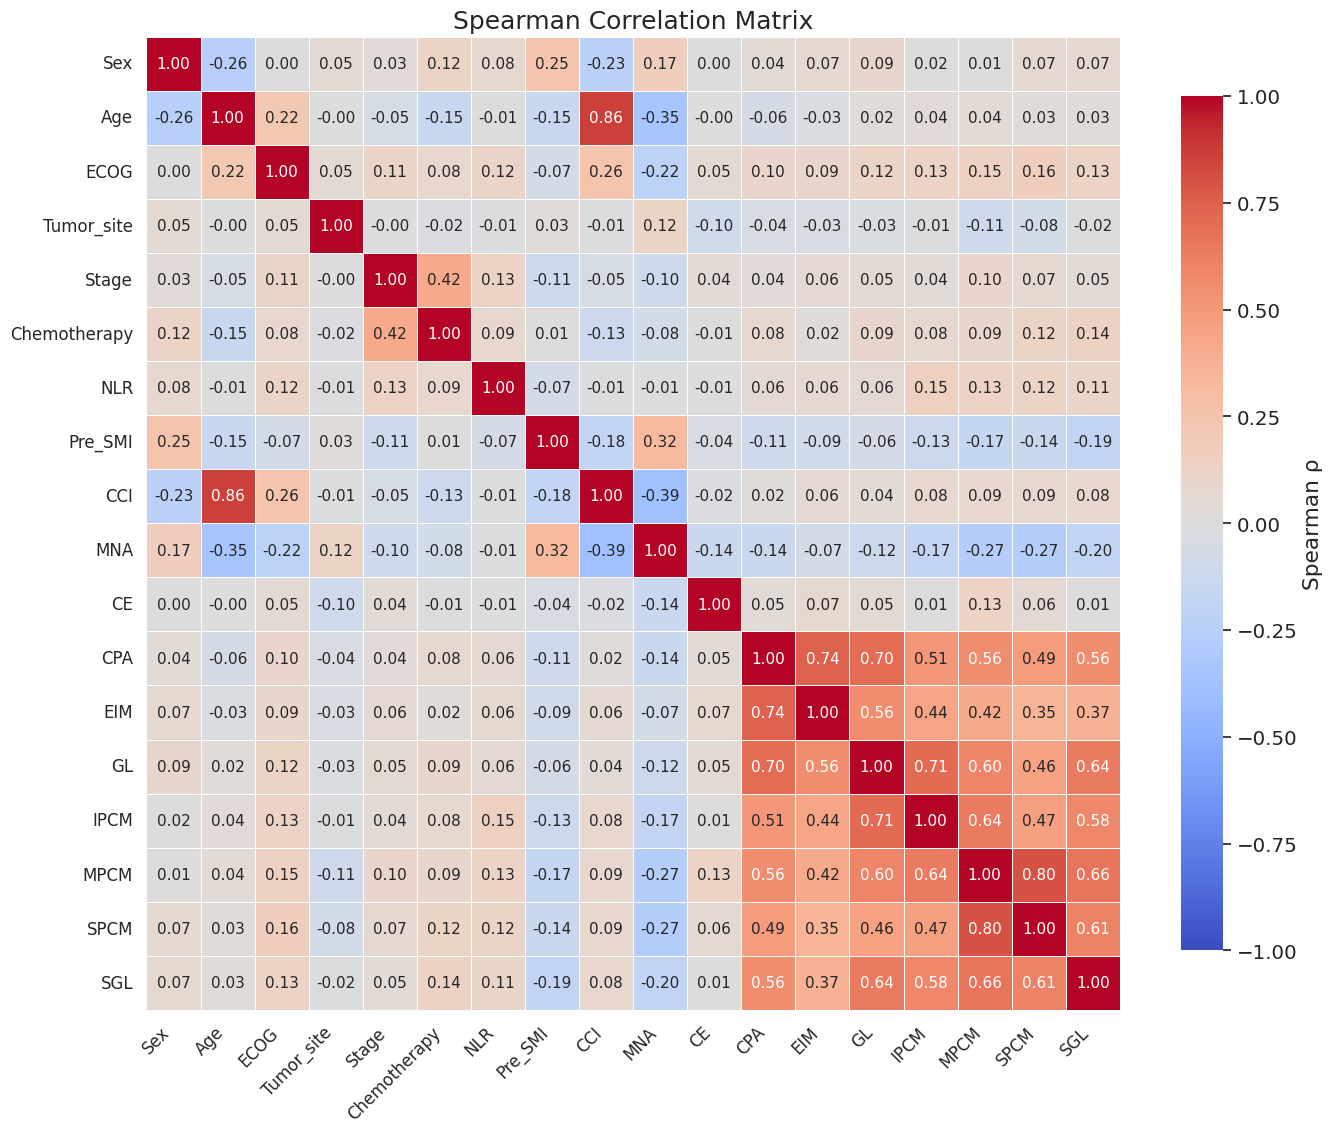

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 計算 Spearman 相關係數
features_to_analyze = train_set.drop(columns=["ID", "Institute", "Group", "Muscle_loss"])
spearman_corr = features_to_analyze.corr(method='spearman')

sns.set(style="white", font_scale=1.3)

# 繪製熱圖
plt.figure(figsize=(14, 12))
sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",     
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.6,
    linecolor='white',
    square=True,
    annot_kws={"size": 11},  # 正常字體大小、不加粗
    cbar_kws={"shrink": 0.8, "label": "Spearman ρ"}
)

# 顯示圖表
plt.title("Spearman Correlation Matrix", fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


# 資料匯入與定義xy


In [2]:
import pandas as pd
# 讀取 Train70 工作表
train_set = pd.read_excel("RTOC_provide20251009_model2_grouped.xlsx", sheet_name='Train')

# 讀取 InternalTest30 工作表
internal_test_set = pd.read_excel("RTOC_provide20251009_model2_grouped.xlsx", sheet_name='InternalTest')

In [ ]:
train_set #n=445

In [ ]:
internal_test_set #n=191

In [3]:
# 讀取 ExternalTest 工作表
External_set = pd.read_excel("RTOC_provide20251009_model2_grouped.xlsx", sheet_name='ExternalTest')

In [ ]:
External_set # 388

In [4]:
# 統計並顯示資料集中的類別筆數與比例
def show_class_distribution(df, name="Dataset"):
    counts = df['Muscle_loss'].value_counts().sort_index()
    proportions = df['Muscle_loss'].value_counts(normalize=True).sort_index() * 100
    summary = pd.DataFrame({
        'Label': counts.index,
        'Count': counts.values,
        'Proportion (%)': proportions.round(2).values
    })
    print(f"\n📊 {name} 分類分布:")
    print(summary.to_string(index=False))

# 顯示訓練集與測試集的分類比例
show_class_distribution(train_set, name="訓練集 (Train70%)")
show_class_distribution(internal_test_set, name="測試集 (Test30%)")
show_class_distribution(External_set, name="External_set ")


📊 訓練集 (Train70%) 分類分布:
 Label  Count  Proportion (%)
     0    329           73.93
     1    116           26.07

📊 測試集 (Test30%) 分類分布:
 Label  Count  Proportion (%)
     0    141           73.82
     1     50           26.18

📊 External_set  分類分布:
 Label  Count  Proportion (%)
     0    290           74.74
     1     98           25.26


In [5]:
# 定義模型使用的特徵欄位
feature_cols = [
    "Sex", "Age", "ECOG", "Tumor_site", "Stage", "Chemotherapy",
    "NLR", "Pre_SMI", "CCI", "MNA", "CE", "CPA",
    "EIM", "GL", "IPCM", "MPCM", "SPCM", "SGL",
]
# 定義目標欄位
target_col = "Muscle_loss"

# Training set
X_train70 = train_set[feature_cols].copy()
y_train70 = train_set[target_col].copy()

# Internal validation set
X_test30 = internal_test_set[feature_cols].copy()
y_test30 = internal_test_set[target_col].copy()

# External validation set
X_external = External_set[feature_cols].copy()
y_external = External_set[target_col].copy()

print("Train:", X_train70.shape, y_train70.shape)
print("Internal:", X_test30.shape, y_test30.shape)
print("External:", X_external.shape, y_external.shape)

Train: (445, 18) (445,)
Internal: (191, 18) (191,)
External: (388, 18) (388,)


# boostrap

In [6]:
import numpy as np
import pandas as pd
import optuna

from tqdm.notebook import tqdm
from optuna.samplers import TPESampler
from imblearn.over_sampling import SMOTENC

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score
)

GLOBAL_RANDOM_SEED = 42
# 定義連續型特徵
continuous_cols = [
    "Age", "NLR", "Pre_SMI", "CCI", "MNA", "CE", "CPA",
    "EIM", "GL", "IPCM", "MPCM", "SPCM", "SGL"
]

In [7]:
# 共用指標函式：根據真實標籤與預測機率，計算 Bootstrap 的分類效能指標
def calculate_bootstrap_metrics(y_true, y_prob, threshold=0.5):
    # 將預測機率轉換為預測類別
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    # 計算並回傳各項二元分類指標
    return {
        "auc": roc_auc_score(y_true, y_prob),
        "aucpr": average_precision_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred),
        "sensitivity": recall_score(y_true, y_pred, pos_label=1),
        "specificity": recall_score(y_true, y_pred, pos_label=0),
        "precision": precision_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
    }

In [20]:
import numpy as np
import pandas as pd
from IPython.display import display
# 彙整 Bootstrap 各項指標的平均值與 95% 信賴區間
def summarize_bootstrap(bootstrap_output):
    # 取得各輪 Bootstrap 的模型評估結果
    results_df = bootstrap_output["results_df"].copy()
    # 設定表格顯示名稱及其對應的結果欄位
    metrics = {
        "AUC": "auc",
        "AUCPR": "aucpr",
        "F1-score": "f1",
        "Accuracy": "accuracy",
        "Sensitivity": "sensitivity",
        "Specificity": "specificity",
        "Precision": "precision",
    }
    # 逐一計算各項指標的平均值與 95% 信賴區間
    summary = {}
    for display_name, column in metrics.items():
        if column in results_df.columns:
            values = results_df[column].dropna()
            summary[display_name] = {
                "Mean": values.mean(),
                "95% CI Lower": np.percentile(values, 2.5),
                "95% CI Upper": np.percentile(values, 97.5),
            }

    summary_df = pd.DataFrame(summary).T
    display(summary_df)
     #回傳表格
    return summary_df

In [8]:
# 共用 Bootstrap／Optuna 函式
def run_bootstrap_optuna(X, y, model_name, suggest_params, build_model, continuous_cols,
                         n_bootstrap=500, n_trials=30, sample_ratio=0.7,
                         threshold=0.5, global_seed=42):
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    # 保存各輪評估結果及所有 OOB 預測資料
    bootstrap_results = []
    all_y_true, all_y_prob, all_y_id = [], [], []

    # 每個模型呼叫時重新固定 seed，還原原本相同抽樣序列
    np.random.seed(global_seed)
    # 分辨連續型與類別型特徵，並建立固定的特徵順序及類別索引
    categorical_cols = [col for col in X.columns if col not in continuous_cols]
    feature_order = list(continuous_cols) + categorical_cols
    categorical_indices = list(range(len(continuous_cols), len(feature_order)))
      # 重複執行 Bootstrap 驗證
    for i in tqdm(range(n_bootstrap), desc=f"{model_name} Bootstrap Validation Progress"):
        # 以有放回方式抽取指定比例的樣本作為訓練資料
        boot_indices = np.random.choice(
            len(X), size=int(sample_ratio * len(X)), replace=True
        )
        # 將未被抽中的樣本作為OOB
        oob_indices = list(set(range(len(X))) - set(boot_indices))

        print(f"[{i + 1}/{n_bootstrap}] OOB samples: {len(oob_indices)}")
        # 若 OOB 樣本數過少，跳過該輪 Bootstrap
        if len(oob_indices) < 0.1 * len(X):
            print(f"[Bootstrap {i}] skipped: only {len(oob_indices)} OOB samples")
            continue
        # 建立該輪的 Bootstrap 訓練集與 OOB 驗證集
        X_boot, y_boot = X.iloc[boot_indices], y.iloc[boot_indices]
        X_val, y_val = X.iloc[oob_indices], y.iloc[oob_indices]
        # 依照固定的特徵順序整理訓練集與驗證集
        X_boot_ordered = X_boot[feature_order].to_numpy()
        X_val_ordered = X_val[feature_order].to_numpy()
         # 在第一輪顯示 SMOTENC 使用的特徵類型及索引
        if i == 0:
            print("\n--- SMOTENC 特徵驗證 (i=0) ---")
            print("連續特徵：", continuous_cols)
            print("類別特徵：", categorical_cols)
            print("類別索引：", categorical_indices)
            print("--- 驗證結束 ---\n")
        # 對 Bootstrap 訓練集執行 SMOTENC 過採樣
        smote = SMOTENC(
            categorical_features=categorical_indices,
            random_state=global_seed + i
        )
        X_boot_res, y_boot_res = smote.fit_resample(X_boot_ordered, y_boot)
        # 定義 Optuna 目標函式，以 OOB AUC 作為超參數選擇依據
        def objective(trial):
            # 取得本次試驗使用的超參數
            params = suggest_params(trial)
            # 建立並訓練超參數搜尋階段的模型
            model = build_model(
                params=params, iteration=i, tuning=True, global_seed=global_seed
            )
            model.fit(X_boot_res, y_boot_res)
            # 預測 OOB 樣本屬於正類別的機率
            y_prob = model.predict_proba(X_val_ordered)[:, 1]
            # 回傳 OOB AUC，供 Optuna 進行最佳化
            return roc_auc_score(y_val, y_prob)
        # 建立 Optuna study，搜尋使 OOB AUC 最大化的超參數
        study = optuna.create_study(
            direction="maximize",
            sampler=TPESampler(seed=global_seed + i)
        )
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
        # 取得該輪最佳超參數，並重新建立最終模型
        best_params = study.best_params
        best_model = build_model(
            params=best_params, iteration=i, tuning=False, global_seed=global_seed
        )
        best_model.fit(X_boot_res, y_boot_res)
         # 計算最佳模型在 OOB 驗證集上的預測機率與評估指標
        y_prob = best_model.predict_proba(X_val_ordered)[:, 1]
        metrics = calculate_bootstrap_metrics(y_val, y_prob, threshold)
         # 保存該輪的模型名稱、評估指標及最佳超參數
        bootstrap_results.append({
            "bootstrap_iteration": i,
            "model": model_name,
            **metrics,
            "params": best_params
        })

        all_y_true.extend(y_val.tolist())
        all_y_prob.extend(y_prob.tolist())
        all_y_id.extend(oob_indices)
         # 累積所有輪次的 OOB 真實標籤、預測機率及樣本索引
        print(
            f"[{model_name} Bootstrap {i}] "
            f"AUC: {metrics['auc']:.3f}, AUCPR: {metrics['aucpr']:.3f}, "
            f"F1: {metrics['f1']:.3f}, Sen: {metrics['sensitivity']:.3f}, "
            f"Spe: {metrics['specificity']:.3f}, Pre: {metrics['precision']:.3f}, "
            f"Acc: {metrics['accuracy']:.3f}"
        )

    return {
        "results": bootstrap_results,
        "results_df": pd.DataFrame(bootstrap_results),
        "all_y_true": all_y_true,
        "all_y_prob": all_y_prob,
        "all_y_id": all_y_id,
        "feature_order": feature_order,
        "continuous_cols": list(continuous_cols),
        "categorical_cols": categorical_cols,
        "categorical_indices": categorical_indices,
    }


In [12]:
# 保存每一輪指標與參數
def export_bootstrap_logs(output, model_name, output_folder):
    # 取得各輪 Bootstrap 的評估結果
    results_df = output["results_df"].copy()
    # 將每輪的最佳超參數展開為個別欄位
    params_df = results_df["params"].apply(pd.Series).add_prefix("param_")
    # 合併模型評估指標與最佳超參數
    detailed_df = pd.concat([results_df.drop(columns=["params"]), params_df], axis=1)
    # 儲存每輪 Bootstrap 的評估指標與超參數
    detailed_df.to_csv(
        os.path.join(output_folder, f"{model_name}_Bootstrap_Detailed_Logs.csv"),
        index=False,
        encoding="utf-8-sig",
    )
    # 整理所有 Bootstrap 輪次中的 OOB 預測結果
    oob_df = pd.DataFrame({
        "Sample_Index": output["all_y_id"],
        "y_true": output["all_y_true"],
        "y_prob": output["all_y_prob"],
    })
    # 儲存 OOB 樣本索引、真實標籤及預測機率
    oob_df.to_csv(
        os.path.join(output_folder, f"{model_name}_Bootstrap_OOB_Predictions.csv"),
        index=False,
        encoding="utf-8-sig",
    )

    print(f"{model_name} bootstrap CSV 已保存")

# 挑選最佳超參數、模型重訓練、驗證流程

In [13]:
# 選擇平均 AUC 最佳參數
def select_best_mean_auc_params(bootstrap_output, model_name):
    # 取得指定模型的各輪 Bootstrap 結果
    results_df = bootstrap_output["results_df"].copy()
    results_df = results_df[results_df["model"] == model_name].copy()
    # 若沒有符合模型名稱的結果，則停止執行
    if results_df.empty:
        raise ValueError(f"找不到 {model_name} 的 bootstrap 結果")

    results_df["param_key"] = results_df["params"].apply(
        lambda params: tuple(sorted(params.items()))
    )
    # 依完整參數組合分組，計算 AUC 的平均值、標準差及出現次數
    grouped = (
        results_df.groupby("param_key")["auc"]
        .agg(["mean", "std", "count"])
        .sort_values("mean", ascending=False)
    )
    # 取得平均 OOB AUC 排名第一的參數組合
    best_params = dict(grouped.index[0])
    # 顯示最佳參數及其統計結果
    print(f"\n⭐ {model_name} 平均 OOB AUC 最佳參數：")
    print(best_params)
    print(f"Mean AUC：{grouped.iloc[0]['mean']:.6f}")
    print(f"Count：{int(grouped.iloc[0]['count'])}")

    return best_params, grouped

In [14]:
# 建立最終模型
def build_final_model(model_name, params, random_seed=42):
    # 建立 Random Forest 最終模型
    if model_name == "RandomForest":
        return RandomForestClassifier(
            **params, random_state=random_seed, n_jobs=-1
        )
    # 建立 XGBoost 最終模型
    if model_name == "XGBoost":
        return XGBClassifier(
            **params, eval_metric="auc",
            random_state=random_seed, n_jobs=-1
        )
    # 建立 CatBoost 最終模型
    if model_name == "CatBoost":
        return CatBoostClassifier(
            **params, random_seed=random_seed, verbose=0
        )

    raise ValueError(f"不支援的模型：{model_name}")

In [15]:
# 評估指標
def evaluate_final_model(model, X_ordered, y_true, threshold=0.5):
    # 取得模型預測為正類別的機率
    y_prob = model.predict_proba(X_ordered)[:, 1]
    # 依照指定閾值將預測機率轉換為預測類別
    y_pred = (y_prob >= threshold).astype(int)

    # 計算各項二元分類效能指標
    metrics = {
        "auc": roc_auc_score(y_true, y_prob),
        "aucpr": average_precision_score(y_true, y_prob),
        "f1": f1_score(y_true, y_pred),
        "sensitivity": recall_score(y_true, y_pred, pos_label=1),
        "specificity": recall_score(y_true, y_pred, pos_label=0),
        "precision": precision_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
    }

    return metrics, y_prob, y_pred

In [16]:
# 選參數、重訓、內外部驗證共用函式
def run_final_model_pipeline(model_name, bootstrap_output, X_train, y_train,
                             X_internal, y_internal, X_external, y_external,
                             threshold=0.5, random_seed=42):
    # 使用 bootstrap 時保存的特徵順序，確保完全一致
    feature_order = bootstrap_output["feature_order"]
    continuous_cols = bootstrap_output["continuous_cols"]
    categorical_indices = bootstrap_output["categorical_indices"]

    # 1. 平均 OOB AUC 最佳參數
    best_params, parameter_groups = select_best_mean_auc_params(
        bootstrap_output, model_name
    )

    # 2. 三個資料集依相同特徵順序排列
    X_train_ordered = X_train[feature_order].to_numpy()
    X_internal_ordered = X_internal[feature_order].to_numpy()
    X_external_ordered = X_external[feature_order].to_numpy()

    # 3. SMOTENC 只套用完整 Train70
    smote = SMOTENC(
        categorical_features=categorical_indices,
        random_state=random_seed
    )
    X_train_final, y_train_final = smote.fit_resample(
        X_train_ordered, y_train
    )

    # 4. 最終模型重訓
    final_model = build_final_model(
        model_name, best_params, random_seed
    )
    final_model.fit(X_train_final, y_train_final)

    # 5. Internal validation
    internal_metrics, internal_prob, internal_pred = evaluate_final_model(
        final_model, X_internal_ordered, y_internal, threshold
    )

    # 6. External validation
    external_metrics, external_prob, external_pred = evaluate_final_model(
        final_model, X_external_ordered, y_external, threshold
    )

    print(f"\n🔍 {model_name} Internal Validation")
    for name, value in internal_metrics.items():
        print(f"{name}: {value:.4f}")

    print(f"\n🔍 {model_name} External Validation")
    for name, value in external_metrics.items():
        print(f"{name}: {value:.4f}")

    return {
        "model": final_model,
        "best_params": best_params,
        "parameter_groups": parameter_groups,
        "feature_order": feature_order,
        "continuous_cols": continuous_cols,
        "categorical_indices": categorical_indices,
        "X_train_ordered": X_train_ordered,
        "X_train_final": X_train_final,
        "y_train_final": np.asarray(y_train_final),
        "X_internal_ordered": X_internal_ordered,
        "X_external_ordered": X_external_ordered,
        "internal_metrics": internal_metrics,
        "internal_prob": internal_prob,
        "internal_pred": internal_pred,
        "external_metrics": external_metrics,
        "external_prob": external_prob,
        "external_pred": external_pred,
    }

In [32]:
# 保存結果
import os
import joblib
import numpy as np
import pandas as pd
import sklearn

def save_model_shap_bundle(model_name, final_output, X_train, y_train, X_internal, y_internal,
                           X_external, y_external, train_ids, internal_ids, external_ids,
                           output_folder="Model_2_Results_include"):
    model_folder = os.path.join(output_folder, model_name)
    os.makedirs(model_folder, exist_ok=True)

    feature_order = final_output["feature_order"]

    bundle = {
        "model_name": model_name,
        "model": final_output["model"],
        "best_params": final_output["best_params"],

        # 模型實際接收的資料：連續特徵在前、類別特徵在後
        "X_train_smotenc": np.asarray(final_output["X_train_final"]),
        "y_train_smotenc": np.asarray(final_output["y_train_final"]),
        "X_train_ordered": X_train[feature_order].to_numpy(),
        "X_internal_ordered": np.asarray(final_output["X_internal_ordered"]),
        "X_external_ordered": np.asarray(final_output["X_external_ordered"]),

        # 原始 DataFrame：dependence plot、force plot 使用
        "X_train_raw": X_train.copy(),
        "X_internal_raw": X_internal.copy(),
        "X_external_raw": X_external.copy(),

        # 真實標籤
        "y_train": np.asarray(y_train),
        "y_internal": np.asarray(y_internal),
        "y_external": np.asarray(y_external),

        # 病人 ID
        "train_ids": np.asarray(train_ids),
        "internal_ids": np.asarray(internal_ids),
        "external_ids": np.asarray(external_ids),

        # 預測結果
        "internal_prob": np.asarray(final_output["internal_prob"]),
        "internal_pred": np.asarray(final_output["internal_pred"]),
        "external_prob": np.asarray(final_output["external_prob"]),
        "external_pred": np.asarray(final_output["external_pred"]),

        # 特徵資訊
        "feature_order": list(feature_order),
        "continuous_cols": list(final_output["continuous_cols"]),
        "categorical_cols": [
            col for col in feature_order
            if col not in final_output["continuous_cols"]
        ],
        "categorical_indices": [
            i for i, col in enumerate(feature_order)
            if col not in final_output["continuous_cols"]
        ],

        "threshold": 0.5,
        "random_seed": 42,
        "sklearn_version": sklearn.__version__,
    }

    save_path = os.path.join(model_folder, f"{model_name}_SHAP_Bundle.pkl")
    joblib.dump(bundle, save_path)

    # 額外輸出內外部預測 CSV
    pd.DataFrame({
        "ID": internal_ids,
        "y_true": y_internal,
        "y_prob": final_output["internal_prob"],
        "y_pred": final_output["internal_pred"],
    }).to_csv(os.path.join(model_folder, f"{model_name}_Internal_Predictions.csv"),
              index=False, encoding="utf-8-sig")

    pd.DataFrame({
        "ID": external_ids,
        "y_true": y_external,
        "y_prob": final_output["external_prob"],
        "y_pred": final_output["external_pred"],
    }).to_csv(os.path.join(model_folder, f"{model_name}_External_Predictions.csv"),
              index=False, encoding="utf-8-sig")

    print(f"{model_name} 模型與 SHAP 資料已保存")
    print(os.path.abspath(save_path))
    return save_path

# RF boostrap

In [9]:
# 定義超參數搜尋範圍
def suggest_rf_params(trial):
    return {
        # 決策樹的數量
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        # 每棵決策樹的最大深度
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        # 節點繼續分裂所需的最少樣本數
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        # 葉節點所需的最少樣本數
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        # 每次節點分裂時考慮的特徵數量
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
    }
# 定義 Random Forest 模型
def build_rf(params, iteration, tuning, global_seed):
    return RandomForestClassifier(
        **params, random_state=42, n_jobs=-1
    )

In [10]:
# 執行 Bootstrap 驗證與 Optuna 超參數搜尋
rf_output = run_bootstrap_optuna(
    X=X_train70,
    y=y_train70,
    model_name="RandomForest",
    suggest_params=suggest_rf_params,
    build_model=build_rf,
    continuous_cols=continuous_cols,
    n_bootstrap=500,
    n_trials=30,
    sample_ratio=0.7,
    global_seed=42,
)

RandomForest Bootstrap Validation Progress:   0%|          | 0/500 [00:00<?, ?it/s]

[1/500] OOB samples: 227

--- SMOTENC 特徵驗證 (i=0) ---
連續特徵： ['Age', 'NLR', 'Pre_SMI', 'CCI', 'MNA', 'CE', 'CPA', 'EIM', 'GL', 'IPCM', 'MPCM', 'SPCM', 'SGL']
類別特徵： ['Sex', 'ECOG', 'Tumor_site', 'Stage', 'Chemotherapy']
類別索引： [13, 14, 15, 16, 17]
--- 驗證結束 ---

[RandomForest Bootstrap 0] AUC: 0.956, AUCPR: 0.865, F1: 0.793, Sen: 0.759, Spe: 0.947, Pre: 0.830, Acc: 0.899
[2/500] OOB samples: 224
[RandomForest Bootstrap 1] AUC: 0.947, AUCPR: 0.858, F1: 0.775, Sen: 0.717, Spe: 0.951, Pre: 0.843, Acc: 0.888
[3/500] OOB samples: 230
[RandomForest Bootstrap 2] AUC: 0.940, AUCPR: 0.854, F1: 0.777, Sen: 0.769, Spe: 0.938, Pre: 0.784, Acc: 0.900
[4/500] OOB samples: 222
[RandomForest Bootstrap 3] AUC: 0.932, AUCPR: 0.882, F1: 0.778, Sen: 0.689, Spe: 0.969, Pre: 0.894, Acc: 0.892
[5/500] OOB samples: 231
[RandomForest Bootstrap 4] AUC: 0.924, AUCPR: 0.841, F1: 0.726, Sen: 0.683, Spe: 0.930, Pre: 0.774, Acc: 0.866
[6/500] OOB samples: 216
[RandomForest Bootstrap 5] AUC: 0.947, AUCPR: 0.897, F1: 0.811

In [21]:
rf_metrics_summary = summarize_bootstrap(rf_output)

,Mean,95% CI Lower,95% CI Upper
AUC,0.935286,0.903288,0.963192
AUCPR,0.861974,0.798368,0.915727
F1-score,0.776170,0.702487,0.839855
Accuracy,0.885088,0.849179,0.920488
Sensitivity,0.768896,0.639211,0.880000
Specificity,0.926638,0.879035,0.968759
Precision,0.789400,0.690633,0.888889


In [18]:
# Bootstrap output
import os
import joblib

output_folder = "Model_2_Results_include"
os.makedirs(output_folder, exist_ok=True)

joblib.dump(
    rf_output,
    os.path.join(output_folder, "RF_Bootstrap_Complete_Output.pkl"),
    compress=3,
)

export_bootstrap_logs(rf_output, "RF", output_folder)

RF bootstrap CSV 已保存


# RF 最佳超參數、模型重訓練、驗證流程

In [27]:
# 執行 Random Forest 的最終模型流程：
# 選擇最佳超參數、使用完整訓練集重訓，並進行內部與外部驗證
rf_final_output = run_final_model_pipeline(
    model_name="RandomForest",
    bootstrap_output=rf_output,
    X_train=X_train70,
    y_train=y_train70,
    X_internal=X_test30,
    y_internal=y_test30,
    X_external=X_external,
    y_external=y_external,
    threshold=0.5,
    random_seed=42,
)


⭐ RandomForest 平均 OOB AUC 最佳參數：
{'max_depth': 6, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 4, 'n_estimators': 254}
Mean AUC：0.972017
Count：1

🔍 RandomForest Internal Validation
auc: 0.9596
aucpr: 0.8499
f1: 0.8000
sensitivity: 0.8800
specificity: 0.8865
precision: 0.7333
accuracy: 0.8848

🔍 RandomForest External Validation
auc: 0.9133
aucpr: 0.8132
f1: 0.7397
sensitivity: 0.8265
specificity: 0.8621
precision: 0.6694
accuracy: 0.8531


In [28]:
# 變數命名 方便後續做圖區分
# 共用資料
X_internal_ordered = rf_final_output["X_internal_ordered"]
X_external_ordered = rf_final_output["X_external_ordered"]

# Random Forest
rf_clf_final = rf_final_output["model"]
rf_final_params_best_auc = rf_final_output["best_params"]
X_rf_train_smotenc = rf_final_output["X_train_final"]
y_rf_train_smotenc = rf_final_output["y_train_final"]
rf_y_pred_test_prob = rf_final_output["internal_prob"]
rf_y_pred_test_label = rf_final_output["internal_pred"]
external_prob_rf = rf_final_output["external_prob"]
external_pred_rf = rf_final_output["external_pred"]

In [33]:
# 存模型與SHAP 資料
rf_bundle_path = save_model_shap_bundle(
    model_name="RandomForest",
    final_output=rf_final_output,
    X_train=X_train70,
    y_train=y_train70,
    X_internal=X_test30,
    y_internal=y_test30,
    X_external=X_external,
    y_external=y_external,
    train_ids=train_set["ID"],
    internal_ids=internal_test_set["ID"],
    external_ids=External_set["ID"],
)

RandomForest 模型與 SHAP 資料已保存
/home/claire901114/碩論_口腔癌/新資料_1010/Model_2_Results_include/RandomForest/RandomForest_SHAP_Bundle.pkl


# XGB boostrap

In [34]:
# 定義 XGBoost 的超參數搜尋範圍
def suggest_xgb_params(trial):
    return {
        # 每棵決策樹的最大深度
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        # 子節點繼續分裂所需的最小權重
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        # 控制節點分裂所需的最低損失改善程度
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        # 每棵樹訓練時使用的樣本比例
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        # 每棵樹訓練時使用的特徵比例
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        # 模型每次更新的學習步幅
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        # L1 
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        # L2 
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        # 模型使用的決策樹數量
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
    }
# 定義 XGBoost 模型
def build_xgb(params, iteration, tuning, global_seed):
    if tuning:
        return XGBClassifier(**params, eval_metric="auc")

    return XGBClassifier(
        **params, eval_metric="auc",
        random_state=global_seed + iteration, n_jobs=-1
    )

In [35]:
# 執行 Bootstrap 驗證與 Optuna 超參數搜尋
xgb_output = run_bootstrap_optuna(
    X=X_train70,
    y=y_train70,
    model_name="XGBoost",
    suggest_params=suggest_xgb_params,
    build_model=build_xgb,
    continuous_cols=continuous_cols,
    n_bootstrap=500,
    n_trials=30,
    sample_ratio=0.7,
    global_seed=42,
)

XGBoost Bootstrap Validation Progress:   0%|          | 0/500 [00:00<?, ?it/s]

[1/500] OOB samples: 227

--- SMOTENC 特徵驗證 (i=0) ---
連續特徵： ['Age', 'NLR', 'Pre_SMI', 'CCI', 'MNA', 'CE', 'CPA', 'EIM', 'GL', 'IPCM', 'MPCM', 'SPCM', 'SGL']
類別特徵： ['Sex', 'ECOG', 'Tumor_site', 'Stage', 'Chemotherapy']
類別索引： [13, 14, 15, 16, 17]
--- 驗證結束 ---

[XGBoost Bootstrap 0] AUC: 0.961, AUCPR: 0.893, F1: 0.817, Sen: 0.810, Spe: 0.941, Pre: 0.825, Acc: 0.907
[2/500] OOB samples: 224
[XGBoost Bootstrap 1] AUC: 0.950, AUCPR: 0.879, F1: 0.840, Sen: 0.917, Spe: 0.902, Pre: 0.775, Acc: 0.906
[3/500] OOB samples: 230
[XGBoost Bootstrap 2] AUC: 0.931, AUCPR: 0.861, F1: 0.804, Sen: 0.827, Spe: 0.933, Pre: 0.782, Acc: 0.909
[4/500] OOB samples: 222
[XGBoost Bootstrap 3] AUC: 0.924, AUCPR: 0.869, F1: 0.807, Sen: 0.754, Spe: 0.957, Pre: 0.868, Acc: 0.901
[5/500] OOB samples: 231
[XGBoost Bootstrap 4] AUC: 0.933, AUCPR: 0.868, F1: 0.760, Sen: 0.767, Spe: 0.912, Pre: 0.754, Acc: 0.874
[6/500] OOB samples: 216
[XGBoost Bootstrap 5] AUC: 0.935, AUCPR: 0.870, F1: 0.772, Sen: 0.772, Spe: 0.918, Pre:

In [36]:
xgb_metrics_summary = summarize_bootstrap(xgb_output)

,Mean,95% CI Lower,95% CI Upper
AUC,0.934288,0.903403,0.961399
AUCPR,0.867428,0.809982,0.921239
F1-score,0.774488,0.706979,0.836759
Accuracy,0.880077,0.845286,0.914414
Sensitivity,0.792617,0.687987,0.892857
Specificity,0.911294,0.856653,0.957067
Precision,0.762163,0.656762,0.867925


In [37]:
# Bootstrap output
joblib.dump(
    xgb_output,
    os.path.join(output_folder, "XGB_Bootstrap_Complete_Output.pkl"),
    compress=3,
)
export_bootstrap_logs(xgb_output, "XGB", output_folder)

XGB bootstrap CSV 已保存


# XGB 最佳超參數、模型重訓練、驗證流程

In [38]:
# 執行 XGBoost 的最終模型流程：
# 選擇最佳超參數、使用完整訓練集重訓，並進行內部與外部驗證
xgb_final_output = run_final_model_pipeline(
    model_name="XGBoost",
    bootstrap_output=xgb_output,
    X_train=X_train70,
    y_train=y_train70,
    X_internal=X_test30,
    y_internal=y_test30,
    X_external=X_external,
    y_external=y_external,
    threshold=0.5,
    random_seed=42,
)


⭐ XGBoost 平均 OOB AUC 最佳參數：
{'colsample_bytree': 0.6380820744091208, 'gamma': 0.010702945531947769, 'learning_rate': 0.09829755132041951, 'max_depth': 4, 'min_child_weight': 4, 'n_estimators': 555, 'reg_alpha': 0.47150766384950643, 'reg_lambda': 0.014782999581552742, 'subsample': 0.7439128151108895}
Mean AUC：0.974927
Count：1

🔍 XGBoost Internal Validation
auc: 0.9475
aucpr: 0.8121
f1: 0.7850
sensitivity: 0.8400
specificity: 0.8936
precision: 0.7368
accuracy: 0.8796

🔍 XGBoost External Validation
auc: 0.8924
aucpr: 0.7894
f1: 0.7037
sensitivity: 0.7755
specificity: 0.8552
precision: 0.6441
accuracy: 0.8351


In [39]:
# 變數命名
# XGBoost
xgb_clf_final = xgb_final_output["model"]
xgb_final_params_best_auc = xgb_final_output["best_params"]
X_xgb_train_smotenc = xgb_final_output["X_train_final"]
y_xgb_train_smotenc = xgb_final_output["y_train_final"]
xgb_y_pred_test_prob = xgb_final_output["internal_prob"]
xgb_y_pred_test_label = xgb_final_output["internal_pred"]
external_prob_xgb = xgb_final_output["external_prob"]
external_pred_xgb = xgb_final_output["external_pred"]


In [40]:
# 存模型與SHAP 資料
xgb_bundle_path = save_model_shap_bundle(
    model_name="XGBoost",
    final_output=xgb_final_output,
    X_train=X_train70,
    y_train=y_train70,
    X_internal=X_test30,
    y_internal=y_test30,
    X_external=X_external,
    y_external=y_external,
    train_ids=train_set["ID"],
    internal_ids=internal_test_set["ID"],
    external_ids=External_set["ID"],
)

XGBoost 模型與 SHAP 資料已保存
/home/claire901114/碩論_口腔癌/新資料_1010/Model_2_Results_include/XGBoost/XGBoost_SHAP_Bundle.pkl


# Catboost boostrap

In [41]:
# 定義 CatBoost 的超參數搜尋範圍
def suggest_cat_params(trial):
    return {
        # 模型進行迭代訓練的次數
        "iterations": trial.suggest_int("iterations", 100, 600),
        # 模型每次更新的學習步幅
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        # 每棵決策樹的最大深度
        "depth": trial.suggest_int("depth", 3, 8),
        # L2 
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        # 控制 Bootstrap 抽樣的隨機程度
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        # 連續型特徵離散化時使用的區間數量
        "border_count": trial.suggest_int("border_count", 32, 255),
        # 控制節點分裂評分的隨機程度
        "random_strength": trial.suggest_float("random_strength", 0.0, 1.0),
        # 每次建立決策樹時使用的特徵比例
        "rsm": trial.suggest_float("rsm", 0.6, 1.0),
        # 決定是否依照類別分布自動調整類別權重
        "auto_class_weights": trial.suggest_categorical(
            "auto_class_weights", [None, "Balanced"]
        ),
    }
# 定義 CatBoost 模型
def build_catboost(params, iteration, tuning, global_seed):
    if tuning:
        return CatBoostClassifier(
            **params, random_seed=42, verbose=0
        )

    return CatBoostClassifier(
        **params, random_seed=global_seed + iteration, verbose=0
    )

In [42]:
# 執行 Bootstrap 驗證與 Optuna 超參數搜尋
cat_output = run_bootstrap_optuna(
    X=X_train70,
    y=y_train70,
    model_name="CatBoost",
    suggest_params=suggest_cat_params,
    build_model=build_catboost,
    continuous_cols=continuous_cols,
    n_bootstrap=500,
    n_trials=30,
    sample_ratio=0.7,
    global_seed=42,
)

CatBoost Bootstrap Validation Progress:   0%|          | 0/500 [00:00<?, ?it/s]

[1/500] OOB samples: 227

--- SMOTENC 特徵驗證 (i=0) ---
連續特徵： ['Age', 'NLR', 'Pre_SMI', 'CCI', 'MNA', 'CE', 'CPA', 'EIM', 'GL', 'IPCM', 'MPCM', 'SPCM', 'SGL']
類別特徵： ['Sex', 'ECOG', 'Tumor_site', 'Stage', 'Chemotherapy']
類別索引： [13, 14, 15, 16, 17]
--- 驗證結束 ---

[CatBoost Bootstrap 0] AUC: 0.963, AUCPR: 0.886, F1: 0.817, Sen: 0.810, Spe: 0.941, Pre: 0.825, Acc: 0.907
[2/500] OOB samples: 224
[CatBoost Bootstrap 1] AUC: 0.954, AUCPR: 0.864, F1: 0.821, Sen: 0.800, Spe: 0.945, Pre: 0.842, Acc: 0.906
[3/500] OOB samples: 230
[CatBoost Bootstrap 2] AUC: 0.922, AUCPR: 0.833, F1: 0.796, Sen: 0.827, Spe: 0.927, Pre: 0.768, Acc: 0.904
[4/500] OOB samples: 222
[CatBoost Bootstrap 3] AUC: 0.935, AUCPR: 0.895, F1: 0.804, Sen: 0.738, Spe: 0.963, Pre: 0.882, Acc: 0.901
[5/500] OOB samples: 231
[CatBoost Bootstrap 4] AUC: 0.905, AUCPR: 0.837, F1: 0.769, Sen: 0.750, Spe: 0.930, Pre: 0.789, Acc: 0.883
[6/500] OOB samples: 216
[CatBoost Bootstrap 5] AUC: 0.926, AUCPR: 0.857, F1: 0.755, Sen: 0.702, Spe: 0.943

In [43]:
cat_metrics_summary = summarize_bootstrap(cat_output)

,Mean,95% CI Lower,95% CI Upper
AUC,0.936070,0.903995,0.962702
AUCPR,0.864547,0.802468,0.912899
F1-score,0.785715,0.720000,0.847707
Accuracy,0.888164,0.855170,0.921886
Sensitivity,0.789947,0.677706,0.887893
Specificity,0.923172,0.873487,0.964286
Precision,0.786370,0.689886,0.885918


In [44]:
# 保存Bootstrap output
joblib.dump(
    cat_output,
    os.path.join(output_folder, "CatBoost_Bootstrap_Complete_Output.pkl"),
    compress=3,
)
export_bootstrap_logs(cat_output, "CatBoost", output_folder)

CatBoost bootstrap CSV 已保存


# catboost 最佳超參數、模型重訓練、驗證流程

In [46]:
# 執行 catboost 的最終模型流程：
# 選擇最佳超參數、使用完整訓練集重訓，並進行內部與外部驗證
cat_final_output = run_final_model_pipeline(
    model_name="CatBoost",
    bootstrap_output=cat_output,
    X_train=X_train70,
    y_train=y_train70,
    X_internal=X_test30,
    y_internal=y_test30,
    X_external=X_external,
    y_external=y_external,
    threshold=0.5,
    random_seed=42,
)


⭐ CatBoost 平均 OOB AUC 最佳參數：
{'auto_class_weights': None, 'bagging_temperature': 0.5615189659624851, 'border_count': 191, 'depth': 6, 'iterations': 259, 'l2_leaf_reg': 7.061368826632381, 'learning_rate': 0.027468419574087986, 'random_strength': 0.7393160202722082, 'rsm': 0.6869818813324815}
Mean AUC：0.971846
Count：1

🔍 CatBoost Internal Validation
auc: 0.9540
aucpr: 0.8431
f1: 0.7928
sensitivity: 0.8800
specificity: 0.8794
precision: 0.7213
accuracy: 0.8796

🔍 CatBoost External Validation
auc: 0.9039
aucpr: 0.8002
f1: 0.7373
sensitivity: 0.8163
specificity: 0.8655
precision: 0.6723
accuracy: 0.8531


In [47]:
# CatBoost
cat_clf_final = cat_final_output["model"]
cat_final_params_best_auc = cat_final_output["best_params"]
X_cat_train_smotenc = cat_final_output["X_train_final"]
y_cat_train_smotenc = cat_final_output["y_train_final"]
cat_y_pred_test_prob = cat_final_output["internal_prob"]
cat_y_pred_test_label = cat_final_output["internal_pred"]
external_prob_cat = cat_final_output["external_prob"]
external_pred_cat = cat_final_output["external_pred"]

In [48]:
# 存模型與SHAP 資料
cat_bundle_path = save_model_shap_bundle(
    model_name="CatBoost",
    final_output=cat_final_output,
    X_train=X_train70,
    y_train=y_train70,
    X_internal=X_test30,
    y_internal=y_test30,
    X_external=X_external,
    y_external=y_external,
    train_ids=train_set["ID"],
    internal_ids=internal_test_set["ID"],
    external_ids=External_set["ID"],
)

CatBoost 模型與 SHAP 資料已保存
/home/claire901114/碩論_口腔癌/新資料_1010/Model_2_Results_include/CatBoost/CatBoost_SHAP_Bundle.pkl


# 三個模型的 ROC 與 PR 曲線

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
# 設定三個模型在圖表中顯示的名稱與顏色
MODEL_NAMES = ["RF", "XGBoost", "CatBoost"]
MODEL_COLORS = ["C0", "C1", "C2"]
# 計算評估指標的平均值與 95% 信賴區間
def metric_ci(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    return np.mean(values), np.percentile(values, 2.5), np.percentile(values, 97.5)
# 繪製三個模型的 ROC 曲線
def plot_three_model_roc(y_true_list, y_prob_list, title, bootstrap_results=None, figsize=(7, 5), save_path=None):
    # 建立 ROC 圖表
    plt.figure(figsize=figsize)

    # 逐一計算並繪製三個模型的 ROC 曲線
    for i, (name, y_true, y_prob) in enumerate(zip(MODEL_NAMES, y_true_list, y_prob_list)):
        y_true, y_prob = np.asarray(y_true), np.asarray(y_prob)
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        # 若提供 Bootstrap 結果，顯示平均 AUC 與 95% 信賴區間
        if bootstrap_results is not None:
            mean, lower, upper = metric_ci(bootstrap_results[i]["results_df"]["auc"])
            label = f"{name}, AUC={mean:.3f} ({lower:.3f}, {upper:.3f})"
        # 若未提供 Bootstrap 結果，直接計算該資料集的 AUC
        else:
            label = f"{name}, AUC = {roc_auc_score(y_true, y_prob):.3f}"
        # 繪製該模型的 ROC 曲線
        plt.plot(fpr, tpr, color=MODEL_COLORS[i], linewidth=2.2, label=label)
    # 加入對角參考線
    plt.plot([0, 1], [0, 1], "--", color="steelblue", linewidth=1)
    plt.xlim(-0.02, 1.02)
    plt.ylim(-0.02, 1.02)
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
# 繪製三個模型的 Precision–Recall 曲線
def plot_three_model_pr(y_true_list, y_prob_list, title, bootstrap_results=None,
                        baseline_y=None, figsize=(7, 5), save_path=None):
    # 建立 PR 圖表
    plt.figure(figsize=figsize)

    # 逐一計算並繪製三個模型的 PR 曲線
    for i, (name, y_true, y_prob) in enumerate(zip(MODEL_NAMES, y_true_list, y_prob_list)):
        y_true, y_prob = np.asarray(y_true), np.asarray(y_prob)
        precision, recall, _ = precision_recall_curve(y_true, y_prob)

        # 若提供 Bootstrap 結果，顯示平均 PR-AUC 與 95% 信賴區間
        if bootstrap_results is not None:
            mean, lower, upper = metric_ci(bootstrap_results[i]["results_df"]["aucpr"])
            label = f"{name}, PR-AUC={mean:.3f} ({lower:.3f}, {upper:.3f})"
        # 若未提供 Bootstrap 結果，直接計算該資料集的 PR-AUC
        else:
            label = f"{name}, PR-AUC = {average_precision_score(y_true, y_prob):.3f}"

        # 繪製該模型的 PR 曲線
        plt.plot(recall, precision, color=MODEL_COLORS[i], linewidth=2.2, label=label)

    baseline_y = np.asarray(y_true_list[0] if baseline_y is None else baseline_y)
    prevalence = np.mean(baseline_y)
    plt.axhline(prevalence, color="steelblue", linestyle="--", linewidth=1.2,
                label=f"Baseline ({prevalence:.2f})")
    plt.xlim(-0.02, 1.02)
    plt.ylim(-0.02, 1.02)
    plt.xlabel("Recall (Sensitivity)", fontsize=12)
    plt.ylabel("Precision", fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc="lower left", fontsize=10)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

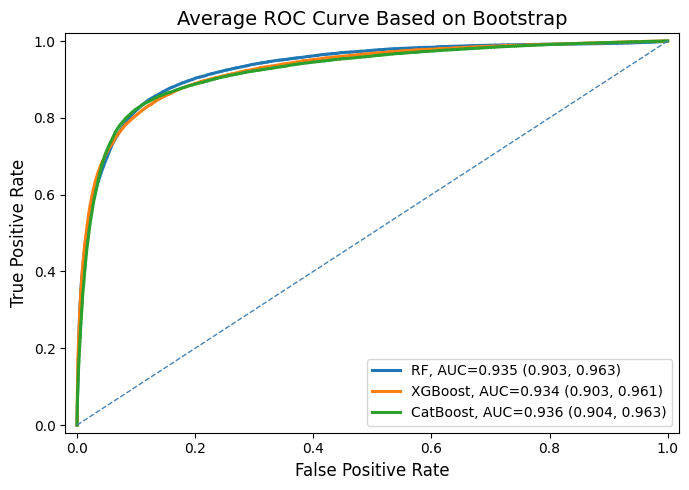

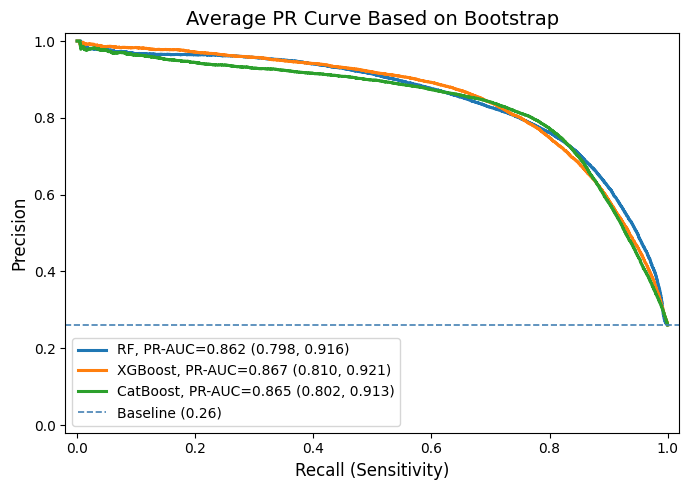

In [50]:
# Bootstrap ROC 與 PR
bootstrap_outputs = [rf_output, xgb_output, cat_output]
# 整理三個模型所有 OOB 樣本的真實標籤
bootstrap_y_true = [
    rf_output["all_y_true"],
    xgb_output["all_y_true"],
    cat_output["all_y_true"],
]

# 整理三個模型所有 OOB 樣本的預測機率
bootstrap_y_prob = [
    rf_output["all_y_prob"],
    xgb_output["all_y_prob"],
    cat_output["all_y_prob"],
]

# 繪製三個模型的 Bootstrap ROC 曲線
plot_three_model_roc(
    bootstrap_y_true,
    bootstrap_y_prob,
    title="Average ROC Curve Based on Bootstrap",
    bootstrap_results=bootstrap_outputs,
)

# 繪製三個模型的 Bootstrap Precision–Recall 曲線
plot_three_model_pr(
    bootstrap_y_true,
    bootstrap_y_prob,
    title="Average PR Curve Based on Bootstrap",
    bootstrap_results=bootstrap_outputs,
)


下午10:26

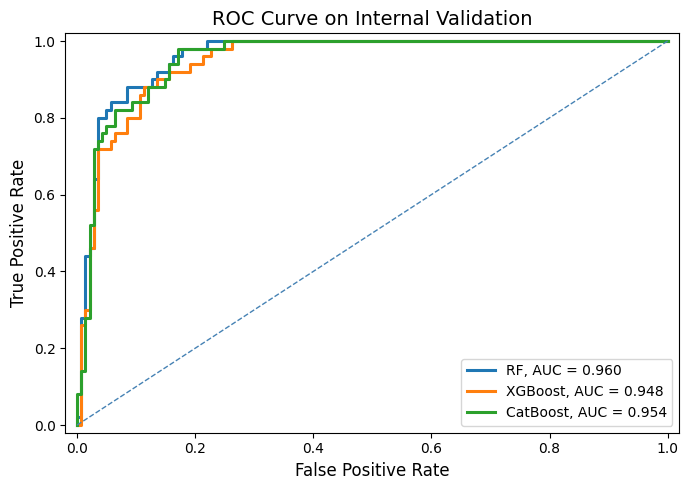

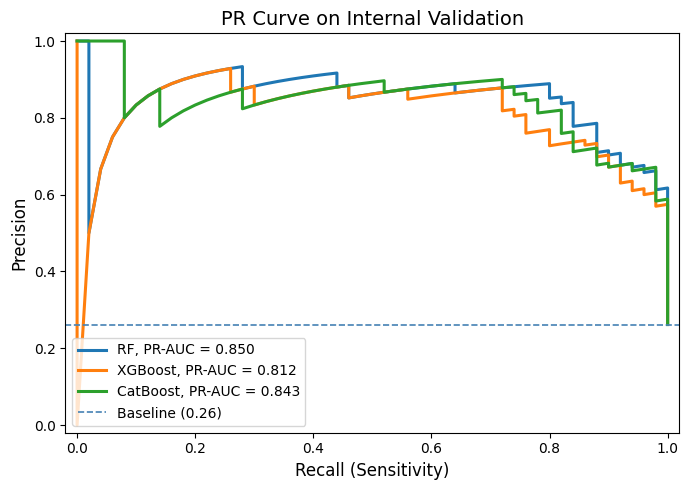

In [51]:
# 內部驗證 ROC 與 PR
internal_y_true = [y_test30, y_test30, y_test30]

# 整理三個最終模型在內部驗證集上的預測機率
internal_y_prob = [
    rf_final_output["internal_prob"],
    xgb_final_output["internal_prob"],
    cat_final_output["internal_prob"],
]

# 繪製三個模型在內部驗證集上的 ROC 曲線
plot_three_model_roc(
    internal_y_true,
    internal_y_prob,
    title="ROC Curve on Internal Validation",
)

# 繪製三個模型在內部驗證集上的 Precision–Recall 曲線
plot_three_model_pr(
    internal_y_true,
    internal_y_prob,
    title="PR Curve on Internal Validation",
    baseline_y=y_test30,
)

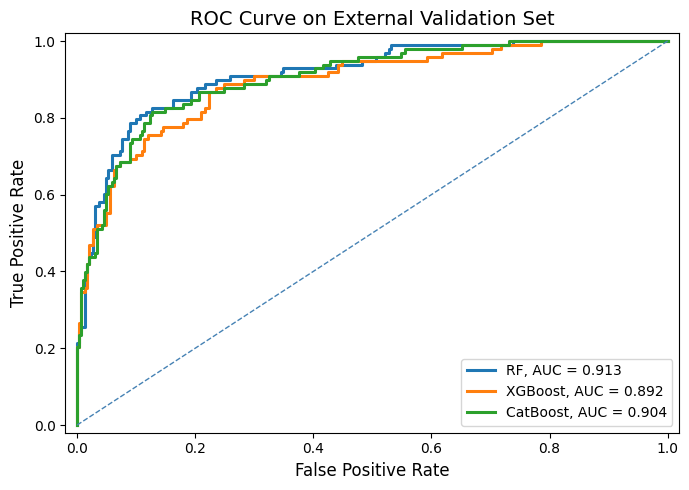

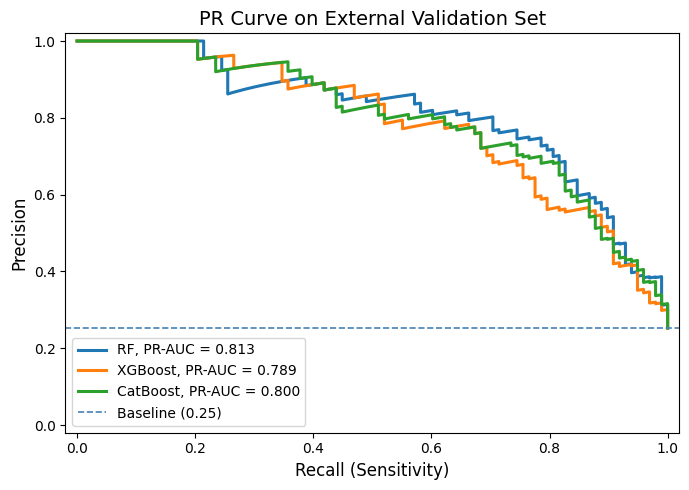

In [52]:
# 外部驗證 ROC 與 PR
external_y_true = [y_external, y_external, y_external]

# 整理三個最終模型在外部驗證集上的預測機率
external_y_prob = [
    rf_final_output["external_prob"],
    xgb_final_output["external_prob"],
    cat_final_output["external_prob"],
]

# 繪製三個模型在外部驗證集上的 ROC 曲線
plot_three_model_roc(
    external_y_true,
    external_y_prob,
    title="ROC Curve on External Validation Set",
)
# 繪製三個模型在外部驗證集上的 Precision–Recall 曲線
plot_three_model_pr(
    external_y_true,
    external_y_prob,
    title="PR Curve on External Validation Set",
    baseline_y=y_external,
)

# Calibration plots


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2
from sklearn.calibration import calibration_curve

# 設定三個模型的標記形狀
MODEL_NAMES = ["Random Forest", "XGBoost", "CatBoost"]
MODEL_LABELS = ["RF", "XGBoost", "CatBoost"]
MODEL_COLORS = ["C0", "C1", "C2"]
MODEL_MARKERS = ["s", "o", "^"]

# 繪製三個模型的校準曲線
def plot_three_model_calibration(y_true_list, y_prob_list, title, n_bins=10,
                                 strategy="quantile", figsize=(7, 6), save_path=None):
    # 建立圖表與對角參考線
    plt.figure(figsize=figsize)
    plt.plot([0, 1], [0, 1], "--", color="steelblue", linewidth=1,
             label="Perfect calibration")
    # 三個模型的校準曲線
    for name, color, marker, y_true, y_prob in zip(
        MODEL_LABELS, MODEL_COLORS, MODEL_MARKERS, y_true_list, y_prob_list
    ):
        # 將樣本分組，計算各組的平均預測機率與實際發生比例
        p_true, p_pred = calibration_curve(
            np.asarray(y_true), np.asarray(y_prob),
            n_bins=n_bins, strategy=strategy
        )
        # 繪製該模型的校準曲線
        plt.plot(p_pred, p_true, marker=marker, color=color,
                 linewidth=2.2, label=name)

    plt.xlim(-0.02, 1.02)
    plt.ylim(-0.02, 1.02)
    plt.xlabel("Predicted Probability", fontsize=12)
    plt.ylabel("Actual Probability", fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc="upper left", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [54]:
# HL 檢定
def hosmer_lemeshow_test(y_true, y_prob, groups=10, eps=1e-12):
    # 將真實標籤與預測機率轉換為一維陣列
    y_true = np.asarray(y_true, dtype=int).ravel()
    y_prob = np.asarray(y_prob, dtype=float).ravel()

    # 移除真實標籤或預測機率中的無效值
    valid = np.isfinite(y_true) & np.isfinite(y_prob)
    y_true, y_prob = y_true[valid], y_prob[valid]

    # 根據預測機率的分位數建立分組邊界
    edges = np.unique(np.quantile(y_prob, np.linspace(0, 1, groups + 1)))
    if len(edges) < 3:
        return np.nan, 0, np.nan, len(edges) - 1

    edges[0], edges[-1] = -np.inf, np.inf
    bin_id = np.digitize(y_prob, edges[1:-1], right=True)
    # 計算實際有效分組數並初始化 HL 統計量
    actual_groups = len(np.unique(bin_id))
    hl_stat = 0.0
    # 逐組比較正、負類別的觀察值與期望值
    for group in np.unique(bin_id):
        mask = bin_id == group
        n = mask.sum()
        observed_1 = y_true[mask].sum()
        expected_1 = y_prob[mask].sum()
        observed_0 = n - observed_1
        expected_0 = n - expected_1
        hl_stat += ((observed_1 - expected_1) ** 2 / (expected_1 + eps)
                    + (observed_0 - expected_0) ** 2 / (expected_0 + eps))
    # 根據實際分組數計算自由度與 p 值
    dof = max(actual_groups - 2, 0)
    p_value = 1 - chi2.cdf(hl_stat, dof) if dof > 0 else np.nan
    return float(hl_stat), int(dof), float(p_value), int(actual_groups)

In [55]:
# Training OOB 會先依真實 sample ID 聚合
def aggregate_oob_predictions(bootstrap_output, agg="mean"):
    # 整理樣本索引、真實標籤及 OOB 預測機率
    df = pd.DataFrame({
        "id": bootstrap_output["all_y_id"],
        "y_true": bootstrap_output["all_y_true"],
        "y_prob": bootstrap_output["all_y_prob"],
    })

    if agg not in {"mean", "median"}:
        raise ValueError("agg 必須是 'mean' 或 'median'")
    # 依樣本索引分組，保留真實標籤並彙整多次 OOB 預測機率
    return df.groupby("id", as_index=False).agg(
        y_true=("y_true", "first"),
        y_prob=("y_prob", agg),
    )

In [56]:
# 比較三個模型的 Hosmer–Lemeshow 檢定結果
def print_three_model_hl(y_true_list, y_prob_list, dataset_name, groups=10):
    # 保存三個模型的檢定結果
    rows = []

    # 分別對三個模型執行 HL 檢定
    for model, y_true, y_prob in zip(MODEL_NAMES, y_true_list, y_prob_list):
        hl, dof, p_value, effective_groups = hosmer_lemeshow_test(
            y_true, y_prob, groups=groups
        )
        # 保存模型名稱、HL 統計量、自由度、p 值及實際分組數
        rows.append({
            "Model": model,
            "HL-stat": hl,
            "df": dof,
            "p-value": p_value,
            "Effective groups": effective_groups,
        })

    result_df = pd.DataFrame(rows)

    print(f"{dataset_name} (Groups={groups})")
    for row in rows:
        print(
            f"{row['Model']:<14}: HL-stat = {row['HL-stat']:.4f}, "
            f"p-value = {row['p-value']:.4f}"
        )

    return result_df

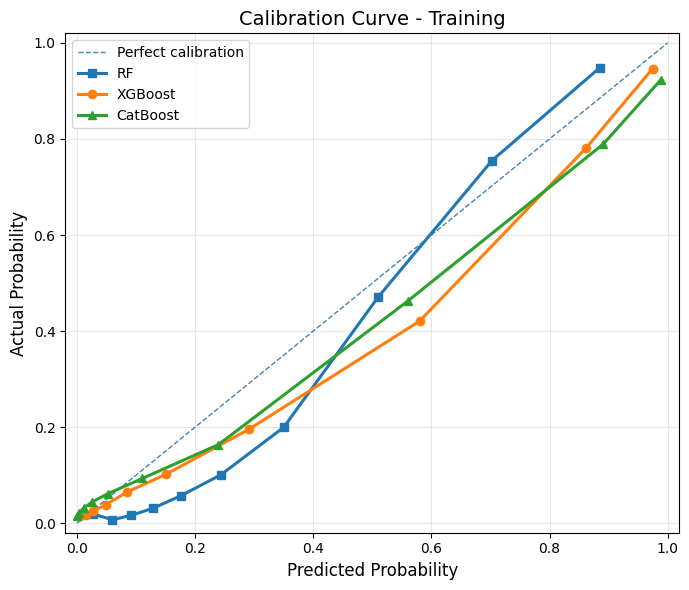

Training OOB Aggregated (Groups=10)
Random Forest : HL-stat = 35.5490, p-value = 0.0000
XGBoost       : HL-stat = 10.9047, p-value = 0.2072
CatBoost      : HL-stat = 6.3963, p-value = 0.6029


In [57]:
# train
# 整理三個模型所有 Bootstrap OOB 樣本的真實標籤
training_y_true = [
    rf_output["all_y_true"],
    xgb_output["all_y_true"],
    cat_output["all_y_true"],
]

# 整理三個模型所有 Bootstrap OOB 樣本的預測機率
training_y_prob = [
    rf_output["all_y_prob"],
    xgb_output["all_y_prob"],
    cat_output["all_y_prob"],
]

# 使用合併後的 OOB 預測資料繪製三個模型的訓練校準曲線
plot_three_model_calibration(
    training_y_true,
    training_y_prob,
    title="Calibration Curve - Training",
)

# 檢定
rf_oob = aggregate_oob_predictions(rf_output)
xgb_oob = aggregate_oob_predictions(xgb_output)
cat_oob = aggregate_oob_predictions(cat_output)

# 使用彙整後的 OOB 預測執行三個模型的 HL 檢定
training_hl = print_three_model_hl(
    y_true_list=[
        rf_oob["y_true"],
        xgb_oob["y_true"],
        cat_oob["y_true"],
    ],
    y_prob_list=[
        rf_oob["y_prob"],
        xgb_oob["y_prob"],
        cat_oob["y_prob"],
    ],
    dataset_name="Training OOB Aggregated",
    groups=10,
)

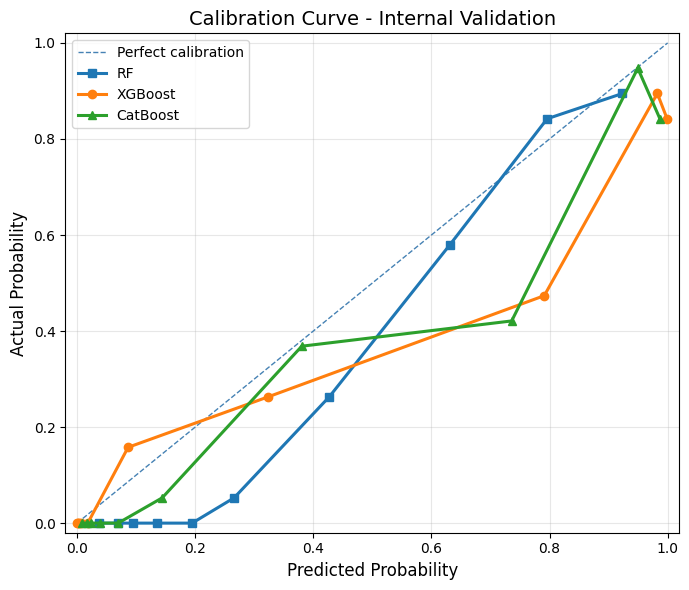

Internal Validation (Groups=10)
Random Forest : HL-stat = 18.9548, p-value = 0.0151
XGBoost       : HL-stat = 541.1397, p-value = 0.0000
CatBoost      : HL-stat = 45.0995, p-value = 0.0000


In [58]:
# Internal validation
# 內部驗證集真實標籤
internal_y_true = [y_test30, y_test30, y_test30]
# 整理三個最終模型在內部驗證集上的預測機率
internal_y_prob = [
    rf_final_output["internal_prob"],
    xgb_final_output["internal_prob"],
    cat_final_output["internal_prob"],
]
# 校準曲線
plot_three_model_calibration(
    internal_y_true,
    internal_y_prob,
    title="Calibration Curve - Internal Validation",
)
# Hosmer–Lemeshow 檢定
internal_hl = print_three_model_hl(
    internal_y_true,
    internal_y_prob,
    dataset_name="Internal Validation",
    groups=10,
)

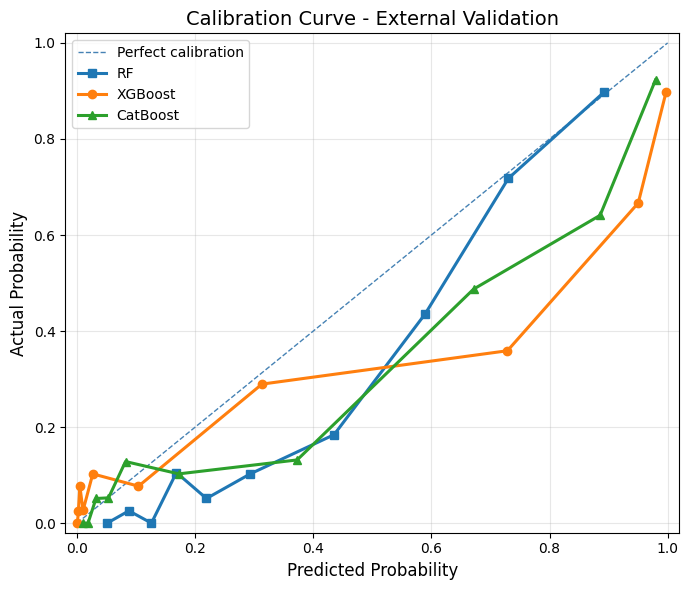

External Validation (Groups=10)
Random Forest : HL-stat = 37.5113, p-value = 0.0000
XGBoost       : HL-stat = 302.9545, p-value = 0.0000
CatBoost      : HL-stat = 48.7187, p-value = 0.0000


In [59]:
# External validation
# 外部驗證集真實標籤
external_y_true = [y_external, y_external, y_external]
# 外部驗證集上的預測機率
external_y_prob = [
    rf_final_output["external_prob"],
    xgb_final_output["external_prob"],
    cat_final_output["external_prob"],
]
# 校準曲線
plot_three_model_calibration(
    external_y_true,
    external_y_prob,
    title="Calibration Curve - External Validation",
)
# Hosmer–Lemeshow 檢定
external_hl = print_three_model_hl(
    external_y_true,
    external_y_prob,
    dataset_name="External Validation",
    groups=10,
)

# Decision curves

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 設定三個模型的顯示名稱與圖表顏色
MODEL_NAMES = ["Random Forest", "XGBoost", "CatBoost"]
MODEL_COLORS = ["C0", "C1", "C2"]

# 計算不同機率閾值下的淨效益
def calculate_net_benefit(y_true, y_prob, thresholds, eps=1e-12):
    # 將真實標籤、預測機率及閾值轉換為 NumPy 陣列
    y_true = np.asarray(y_true, dtype=int).ravel()
    y_prob = np.asarray(y_prob, dtype=float).ravel()
    thresholds = np.asarray(thresholds, dtype=float)
    # 建立陣列，保存各閾值對應的淨效益
    nb = np.empty(len(thresholds))

    # 逐一計算各機率閾值下的真陽性、假陽性及淨效益
    for i, threshold in enumerate(thresholds):
        tp = np.sum((y_prob >= threshold) & (y_true == 1))
        fp = np.sum((y_prob >= threshold) & (y_true == 0))
        # 根據真陽性與假陽性計算該閾值下的淨效益
        nb[i] = tp / len(y_true) - fp / len(y_true) * threshold / max(1 - threshold, eps)
    # 回傳所有閾值對應的淨效益
    return nb

# 計算指定閾值範圍內的淨效益曲線下面積
def dca_area_under_curve(y_true, y_prob, thresholds, t_min=None, t_max=None):
    # 計算所有閾值下的淨效益
    thresholds = np.asarray(thresholds, dtype=float)
    net_benefit = calculate_net_benefit(y_true, y_prob, thresholds)
    # 建立閾值篩選條件
    mask = np.ones(len(thresholds), dtype=bool)

    if t_min is not None:
        mask &= thresholds >= t_min
    if t_max is not None:
        mask &= thresholds <= t_max

    # 確認指定範圍內至少包含兩個閾值，才能計算曲線下面積
    if mask.sum() < 2:
        raise ValueError("指定範圍內至少需要兩個 threshold")

    return np.trapezoid(net_benefit[mask], thresholds[mask])

In [61]:
# DCA 畫圖與 AUNB 計算函式
def run_three_model_dca(y_true_list, y_prob_list, title, thresholds=None,
                        t_min=None, t_max=None, figsize=(8, 6), save_path=None):
    # 若未指定閾值，建立 0.01 至 0.99 的機率閾值
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 100)

    # 將閾值轉換為 NumPy 陣列
    thresholds = np.asarray(thresholds, dtype=float)
    curves, areas = {}, {}
    # 分別計算三個模型的淨效益曲線及 AUNB
    for model, y_true, y_prob in zip(MODEL_NAMES, y_true_list, y_prob_list):
        curves[model] = calculate_net_benefit(y_true, y_prob, thresholds)
        areas[model] = dca_area_under_curve(
            y_true, y_prob, thresholds, t_min=t_min, t_max=t_max
        )

    # Treat All 使用 RF 對應 cohort 的 y_true
    treat_all = calculate_net_benefit(
        y_true_list[0], np.ones(len(y_true_list[0])), thresholds
    )
    # Treat None 的淨效益固定為零
    treat_none = np.zeros_like(thresholds)

    # 計算 Treat All 的淨效益曲線下面積
    areas["Treat All"] = dca_area_under_curve(
        y_true_list[0], np.ones(len(y_true_list[0])),
        thresholds, t_min=t_min, t_max=t_max
    )

    # 建立 DCA 圖表
    plt.figure(figsize=figsize)

    # 繪製三個模型的淨效益曲線
    for model, color in zip(MODEL_NAMES, MODEL_COLORS):
        plt.plot(
            thresholds, curves[model],
            color=color, linewidth=2.2, label=model
        )
    # 加入全部介入（All）的參考曲線
    plt.plot(
        thresholds, treat_all,
        color="black", linestyle="--", alpha=0.5, label="All"
    )
    # 加入完全不介入（None）的參考曲線
    plt.plot(
        thresholds, treat_none,
        color="gray", linestyle=":", alpha=0.8, label="None"
    )

    y_max = np.nanmax([
        curves["Random Forest"].max(),
        curves["XGBoost"].max(),
        curves["CatBoost"].max(),
        treat_all.max(),
    ])

    plt.ylim(-0.05, y_max * 1.2)
    plt.xlim(0, 1.0)
    plt.xlabel("Threshold Probability", fontsize=12)
    plt.ylabel("Net Benefit", fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc="upper right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    # 將各模型及 Treat All 的 AUNB 整理成表格
    area_df = pd.DataFrame({
        "Model": list(areas.keys()),
        "AUNB": list(areas.values()),
    })

    print(f"\n{title} — AUNB")
    # 各模型的 AUNB
    for model, area in areas.items():
        print(f"{model:<14}: {area:.6f}")
    # 回傳閾值、淨效益曲線與 AUNB 結果
    return {
        "thresholds": thresholds,
        "net_benefit": curves,
        "treat_all": treat_all,
        "treat_none": treat_none,
        "area_df": area_df,
    }

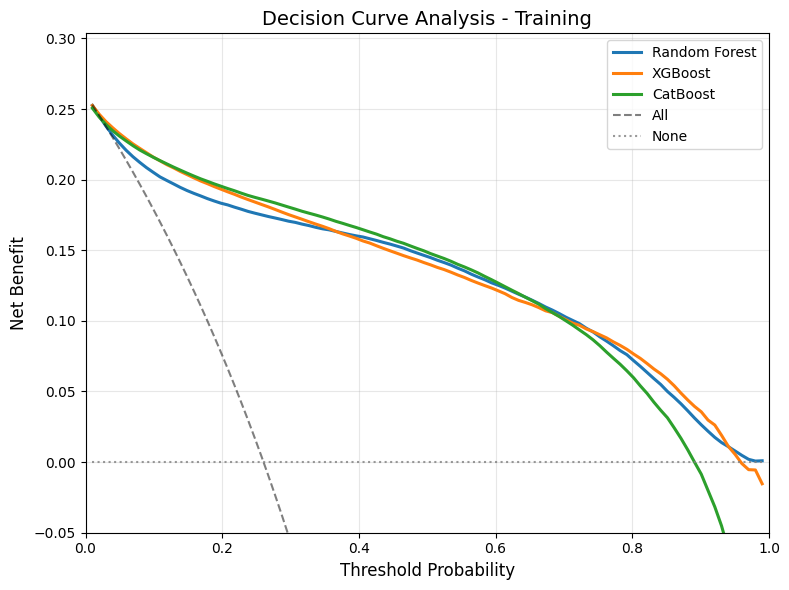


Decision Curve Analysis - Training — AUNB
Random Forest : 0.129013
XGBoost       : 0.131156
CatBoost      : 0.121689
Treat All     : -2.474327


In [62]:
# Training
training_dca = run_three_model_dca(
    y_true_list=[
        rf_output["all_y_true"],
        xgb_output["all_y_true"],
        cat_output["all_y_true"],
    ],
    y_prob_list=[
        rf_output["all_y_prob"],
        xgb_output["all_y_prob"],
        cat_output["all_y_prob"],
    ],
    title="Decision Curve Analysis - Training",
)

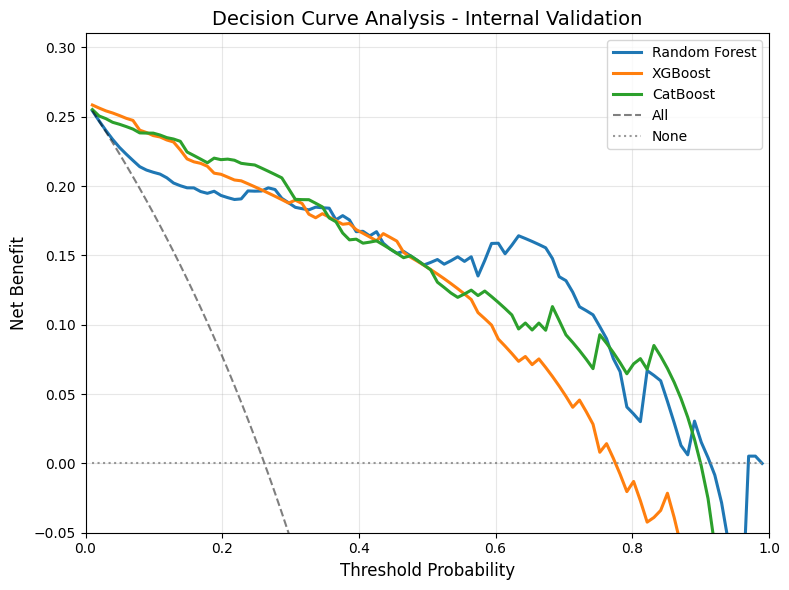


Decision Curve Analysis - Internal Validation — AUNB
Random Forest : 0.134018
XGBoost       : 0.073940
CatBoost      : 0.116467
Treat All     : -2.468128


In [63]:
# Internal validation
internal_dca = run_three_model_dca(
    y_true_list=[y_test30, y_test30, y_test30],
    y_prob_list=[
        rf_final_output["internal_prob"],
        xgb_final_output["internal_prob"],
        cat_final_output["internal_prob"],
    ],
    title="Decision Curve Analysis - Internal Validation",
)

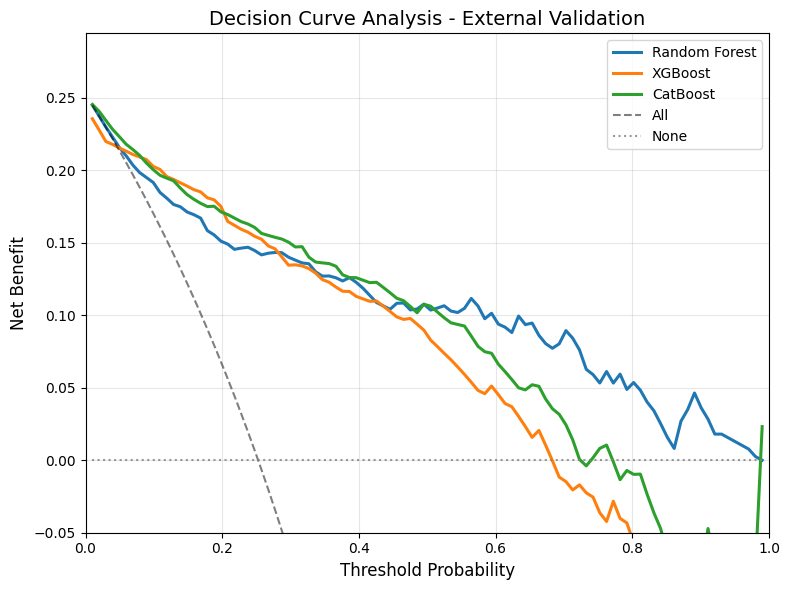


Decision Curve Analysis - External Validation — AUNB
Random Forest : 0.104885
XGBoost       : 0.034335
CatBoost      : 0.081050
Treat All     : -2.511113


In [64]:
# External validation
external_dca = run_three_model_dca(
    y_true_list=[y_external, y_external, y_external],
    y_prob_list=[
        rf_final_output["external_prob"],
        xgb_final_output["external_prob"],
        cat_final_output["external_prob"],
    ],
    title="Decision Curve Analysis - External Validation",
)